In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Dyt-desktop.csv' , sep=';')

In [3]:
df.head()

,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,...,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,Male,No,Yes,7,10,10,0,10,1.0,0.0,...,0,0.000000,0.00,17,2,0,2,0.117647,0.000000,No
1,Female,Yes,Yes,13,12,12,0,12,1.0,0.0,...,4,0.114286,0.00,26,2,2,2,0.076923,0.076923,Yes
2,Female,No,Yes,7,6,6,0,6,1.0,0.0,...,4,0.114286,0.00,26,1,3,1,0.038462,0.115385,No
3,Female,No,Yes,7,0,0,0,0,0.0,0.0,...,0,0.000000,0.00,1,0,0,0,0.000000,0.000000,No
4,Female,No,Yes,8,4,4,0,4,1.0,0.0,...,1,25.000000,0.05,26,2,2,2,0.076923,0.076923,No


In [4]:
df.isnull().sum()

Gender        0
Nativelang    0
Otherlang     0
Age           0
Clicks1       0
             ..
Misses32      0
Score32       0
Accuracy32    0
Missrate32    0
Dyslexia      0
Length: 197, dtype: int64

In [5]:
pd.set_option('display.max_rows', None)
df.dtypes


Gender         object
Nativelang     object
Otherlang      object
Age             int64
Clicks1         int64
Hits1           int64
Misses1         int64
Score1          int64
Accuracy1     float64
Missrate1     float64
Clicks2         int64
Hits2           int64
Misses2         int64
Score2          int64
Accuracy2     float64
Missrate2     float64
Clicks3         int64
Hits3           int64
Misses3         int64
Score3          int64
Accuracy3     float64
Missrate3     float64
Clicks4         int64
Hits4           int64
Misses4         int64
Score4          int64
Accuracy4     float64
Missrate4     float64
Clicks5         int64
Hits5           int64
Misses5         int64
Score5          int64
Accuracy5     float64
Missrate5     float64
Clicks6         int64
Hits6           int64
Misses6         int64
Score6          int64
Accuracy6     float64
Missrate6     float64
Clicks7         int64
Hits7           int64
Misses7         int64
Score7          int64
Accuracy7     float64
Missrate7 

In [6]:
df.describe()

,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,Clicks2,Hits2,Misses2,...,Misses31,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32
count,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,...,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000
mean,10.484907,6.104281,3.683315,0.794731,3.748079,3.047372,4.541253,9.547475,4.844951,0.888310,...,1.263172,2.605653,0.987645,0.512544,19.881175,1.603458,1.954171,1.827936,1.326055,2.172582
std,2.478132,4.473068,4.194311,1.191338,4.172533,35.446814,40.329119,5.462742,3.699285,1.829512,...,1.796283,2.010972,8.078969,4.750193,6.083497,1.030951,1.079002,1.403607,12.355879,15.894841
min,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.750000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2.000000,0.000000,...,0.000000,1.000000,0.034483,0.000000,17.000000,1.000000,1.000000,1.000000,0.045455,0.047619
50%,10.000000,5.000000,1.000000,0.000000,1.000000,0.500000,0.000000,9.000000,4.000000,0.000000,...,1.000000,3.000000,0.064516,0.027027,17.000000,2.000000,2.000000,2.000000,0.076923,0.111111
75%,12.000000,8.000000,7.000000,1.000000,7.000000,1.000000,0.250000,12.000000,8.000000,1.000000,...,2.000000,4.000000,0.114286,0.050000,26.000000,2.000000,3.000000,2.000000,0.115385,0.176471
max,17.000000,84.000000,19.000000,18.000000,19.000000,875.000000,625.000000,104.000000,17.000000,21.000000,...,50.000000,48.000000,125.000000,125.000000,26.000000,4.000000,4.000000,22.000000,125.000000,125.000000


<span style="color:#AB056B; font-weight:700; font-size:50px;">Artificial Samples</span>


In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import  KNeighborsClassifier , NearestNeighbors

def smote_manual(X, y, k=5, random_state=42):
    X_minority = X[y == 1]
    X_majority = X[y == 0]

    if len(X_minority) > len(X_majority):
        X_minority, X_majority = X_majority, X_minority
        minority_label = 0
    else:
        minority_label = 1

    n_minority = len(X_minority)
    n_majority = len(X_majority)
    n_synthetic = n_majority - n_minority

    # Hangi sınıfın azınlık olduğunu teyit ettik
    if n_synthetic <= 0:
        return X, y
    # Azınlık sınıfına KNN (En Yakın Komşu) uyguladık
    knn = NearestNeighbors(n_neighbors=k+1).fit(X_minority)
    distances, indices = knn.kneighbors(X_minority)

    synthetic_samples = []
    np.random.seed(random_state)

    for _ in range(n_synthetic):
        idx = np.random.randint(0, n_minority)
        sample = X_minority.iloc[idx].values
        neighbor_idx = np.random.randint(1, k+1)
        neighbor_sample_idx = indices[idx, neighbor_idx]
        neighbor = X_minority.iloc[neighbor_sample_idx].values

        gap = np.random.random()
        synthetic = sample + gap * (neighbor - sample)
        synthetic_samples.append(synthetic)

    X_synthetic = pd.DataFrame(synthetic_samples, columns=X.columns)
    y_synthetic = pd.Series([minority_label] * n_synthetic)

    # Orijinal ve yeni üretilen yapay verileri birleştiriyoruz
    X_resampled = pd.concat([X, X_synthetic], axis=0)
    y_resampled = pd.concat([y, y_synthetic], axis=0)

    return X_resampled, y_resampled

<span style="color:#04B862; font-weight:700; font-size:50px;">Veri İşleme</span>


In [8]:
df = pd.read_csv('Dyt-desktop.csv' , sep=';')

In [9]:
# Kategorik değişkenleri sayısal verilere çeviriyoruz
from sklearn.preprocessing import LabelEncoder ,OneHotEncoder
le = LabelEncoder()
categorical_cols = ['Gender' , 'Nativelang' , 'Otherlang' , 'Dyslexia']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [10]:
# Bağımsız bağımlı değişkenleri belirliyoruz
X =  df.drop('Dyslexia' , axis=1)
y = df['Dyslexia']
print('SMOTE öncesi sınıf dağılımı')
print(y.value_counts())

SMOTE öncesi sınıf dağılımı
Dyslexia
0    3252
1     392
Name: count, dtype: int64


In [11]:
# Eğitim ve Test seti ayrımı (%80 Eğitim, %20 Test)
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2 , random_state=42)

# SMOTE UYGULUYORUZ
X_train_smote, y_train_smote = smote_manual(X_train, y_train, k=5)
print('SMOTE sonrası eğitim seti sınıf dağılımı')
print(y_train_smote.value_counts())

SMOTE sonrası eğitim seti sınıf dağılımı
0    2603
1    2603
Name: count, dtype: int64


In [12]:
#SCALİNG UYGULADIK
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

<span style="color:#FA1105; font-weight:700; font-size:50px;">MODELS</span>


In [13]:
from sklearn.neighbors import KNeighborsClassifier , NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , AdaBoostClassifier , ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis ,QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "XGBoost": XGBClassifier()
}


     MODEL: Logistic Regression.   
Accuracy : 0.8450
Precision: 0.3922
Recall   : 0.7500
F1 Score : 0.5150
ROC AUC  : 0.8587


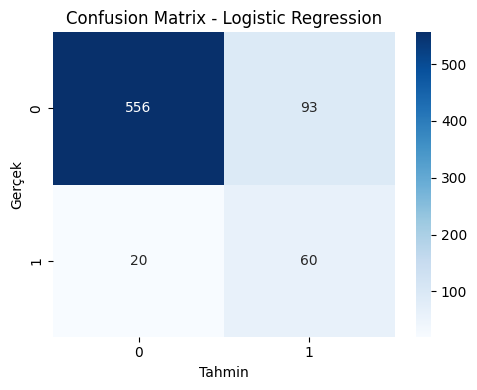

     MODEL: Decision Tree.   
Accuracy : 0.8217
Precision: 0.2340
Recall   : 0.2750
F1 Score : 0.2529
ROC AUC  : 0.5820


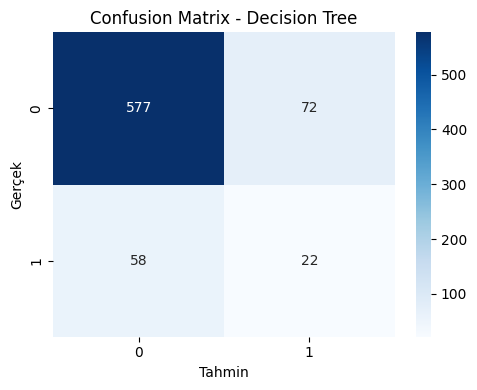

     MODEL: Random Forest.   
Accuracy : 0.8971
Precision: 0.6471
Recall   : 0.1375
F1 Score : 0.2268
ROC AUC  : 0.8458


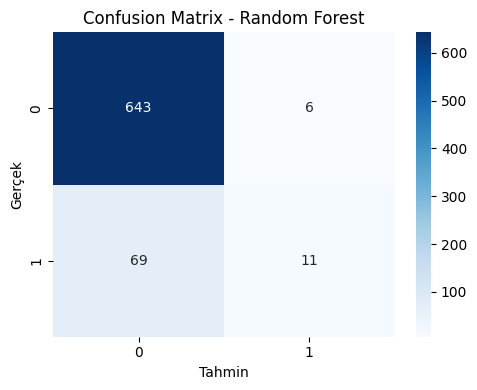

     MODEL: Gradient Boosting.   
Accuracy : 0.9053
Precision: 0.6038
Recall   : 0.4000
F1 Score : 0.4812
ROC AUC  : 0.8682


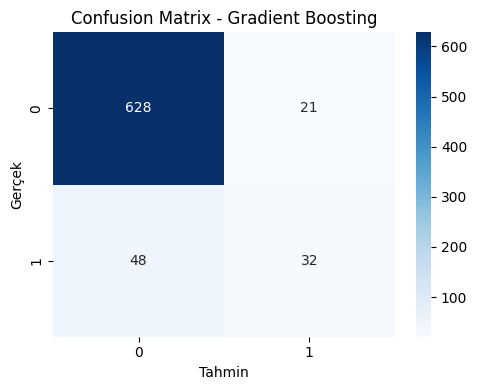

     MODEL: AdaBoost.   
Accuracy : 0.8807
Precision: 0.4624
Recall   : 0.5375
F1 Score : 0.4971
ROC AUC  : 0.8494


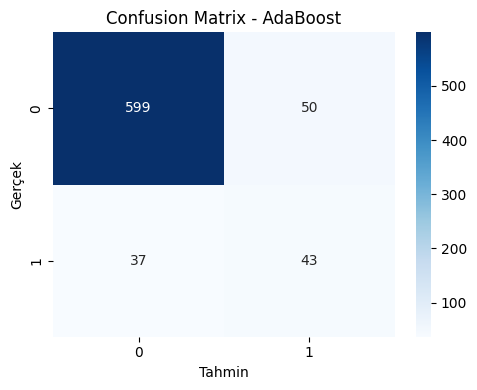

     MODEL: Extra Trees.   
Accuracy : 0.9040
Precision: 0.8125
Recall   : 0.1625
F1 Score : 0.2708
ROC AUC  : 0.8500


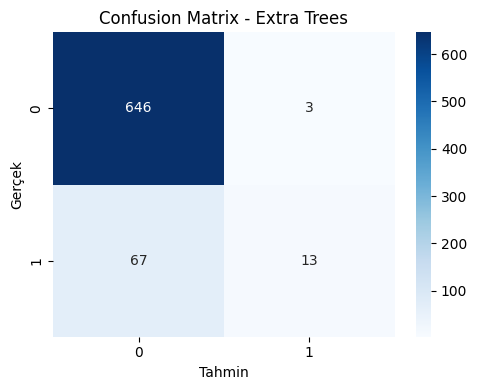

     MODEL: SVM.   
Accuracy : 0.8944
Precision: 0.5161
Recall   : 0.6000
F1 Score : 0.5549
ROC AUC  : 0.8556


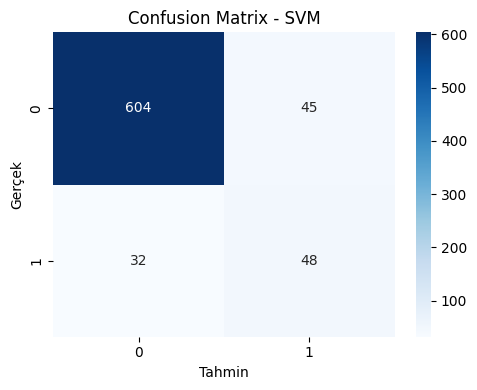

     MODEL: KNN.   
Accuracy : 0.6022
Precision: 0.1912
Recall   : 0.8125
F1 Score : 0.3095
ROC AUC  : 0.7491


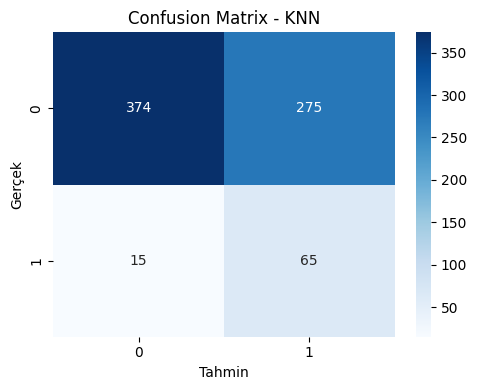

     MODEL: Naive Bayes.   
Accuracy : 0.4568
Precision: 0.1457
Recall   : 0.8125
F1 Score : 0.2471
ROC AUC  : 0.6461


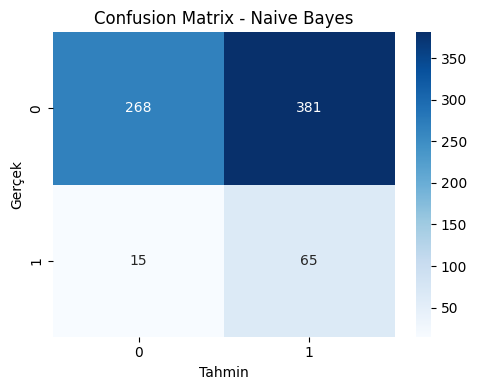

     MODEL: LDA.   
Accuracy : 0.8066
Precision: 0.3333
Recall   : 0.7625
F1 Score : 0.4639
ROC AUC  : 0.8596


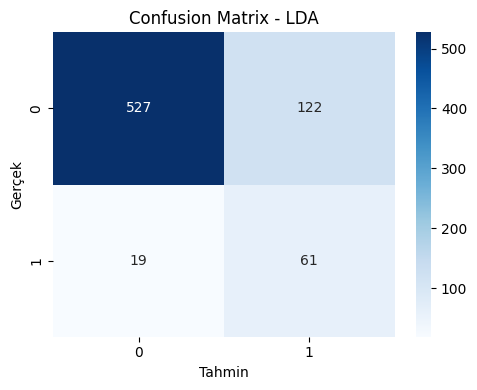

     MODEL: QDA.   
Accuracy : 0.5267
Precision: 0.1594
Recall   : 0.7750
F1 Score : 0.2644
ROC AUC  : 0.6373


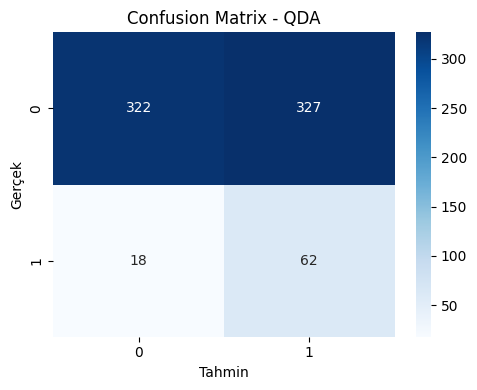

     MODEL: XGBoost.   
Accuracy : 0.9136
Precision: 0.7576
Recall   : 0.3125
F1 Score : 0.4425
ROC AUC  : 0.8623


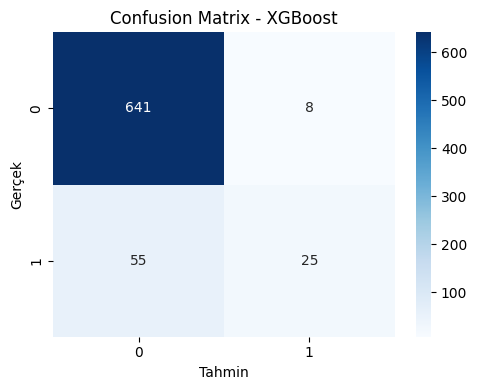

In [15]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_curve  ,  roc_auc_score , confusion_matrix

results = []

for name, model in models.items():
    
    print(f"     MODEL: {name}.   ")
    print("====================================")

    pipe = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # ROC and AUC
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe["model"], "predict_proba") else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    if roc_auc:
        print(f"ROC AUC  : {roc_auc:.4f}")

    results.append([name, acc, prec, rec, f1, roc_auc])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.tight_layout()
    plt.show()

In [16]:
results_df = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
)

print("\n--- Tüm Model Sonuçları ---")
print(results_df)


--- Tüm Model Sonuçları ---
                  Model  Accuracy  Precision  Recall        F1   ROC AUC
0   Logistic Regression  0.844993   0.392157  0.7500  0.515021  0.858725
1         Decision Tree  0.821674   0.234043  0.2750  0.252874  0.582030
2         Random Forest  0.897119   0.647059  0.1375  0.226804  0.845763
3     Gradient Boosting  0.905350   0.603774  0.4000  0.481203  0.868240
4              AdaBoost  0.880658   0.462366  0.5375  0.497110  0.849422
5           Extra Trees  0.903978   0.812500  0.1625  0.270833  0.849961
6                   SVM  0.894376   0.516129  0.6000  0.554913  0.855605
7                   KNN  0.602195   0.191176  0.8125  0.309524  0.749124
8           Naive Bayes  0.456790   0.145740  0.8125  0.247148  0.646052
9                   LDA  0.806584   0.333333  0.7625  0.463878  0.859649
10                  QDA  0.526749   0.159383  0.7750  0.264392  0.637269
11              XGBoost  0.913580   0.757576  0.3125  0.442478  0.862327


In [17]:
results_df = results_df.sort_values(by="F1", ascending=False )
print(results_df)

                  Model  Accuracy  Precision  Recall        F1   ROC AUC
6                   SVM  0.894376   0.516129  0.6000  0.554913  0.855605
0   Logistic Regression  0.844993   0.392157  0.7500  0.515021  0.858725
4              AdaBoost  0.880658   0.462366  0.5375  0.497110  0.849422
3     Gradient Boosting  0.905350   0.603774  0.4000  0.481203  0.868240
9                   LDA  0.806584   0.333333  0.7625  0.463878  0.859649
11              XGBoost  0.913580   0.757576  0.3125  0.442478  0.862327
7                   KNN  0.602195   0.191176  0.8125  0.309524  0.749124
5           Extra Trees  0.903978   0.812500  0.1625  0.270833  0.849961
10                  QDA  0.526749   0.159383  0.7750  0.264392  0.637269
1         Decision Tree  0.821674   0.234043  0.2750  0.252874  0.582030
8           Naive Bayes  0.456790   0.145740  0.8125  0.247148  0.646052
2         Random Forest  0.897119   0.647059  0.1375  0.226804  0.845763


In [21]:
results_df.to_csv("model_sonuclari.csv", index=False)

<span style="color:#04B8AC; font-weight:700; font-size:50px;">ROC AND AUC</span>


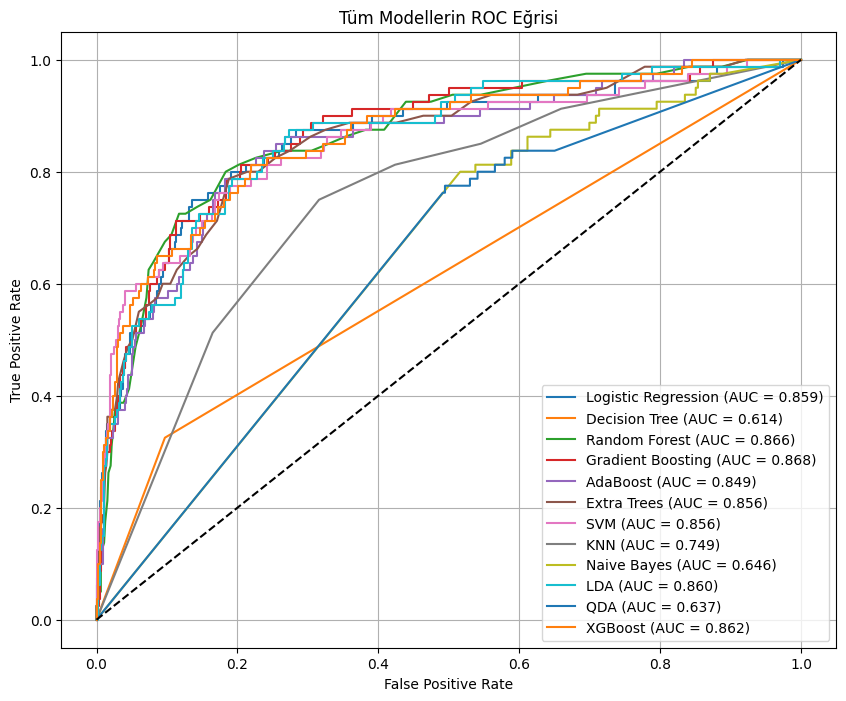

In [18]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)

    if hasattr(pipe['model'], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tüm Modellerin ROC Eğrisi")
plt.legend()
plt.grid()
plt.show()


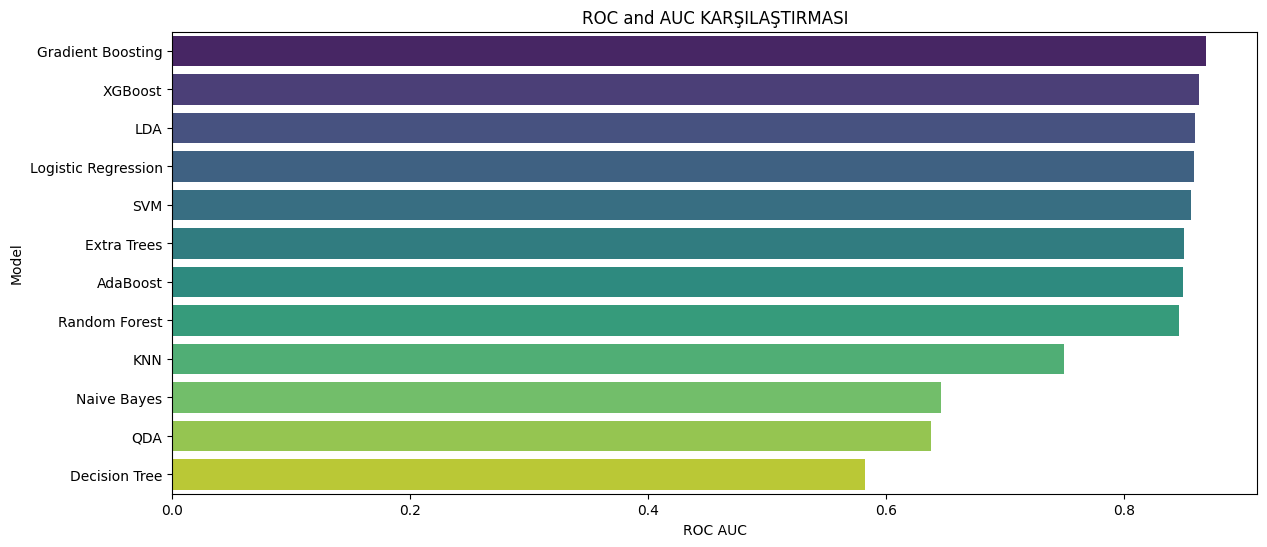

In [19]:
plt.figure(figsize=(14,6))
sns.barplot(data=results_df.sort_values('ROC AUC' , ascending=False),
            x='ROC AUC' , y='Model' , palette='viridis')

plt.title('ROC and AUC KARŞILAŞTIRMASI')
plt.show()

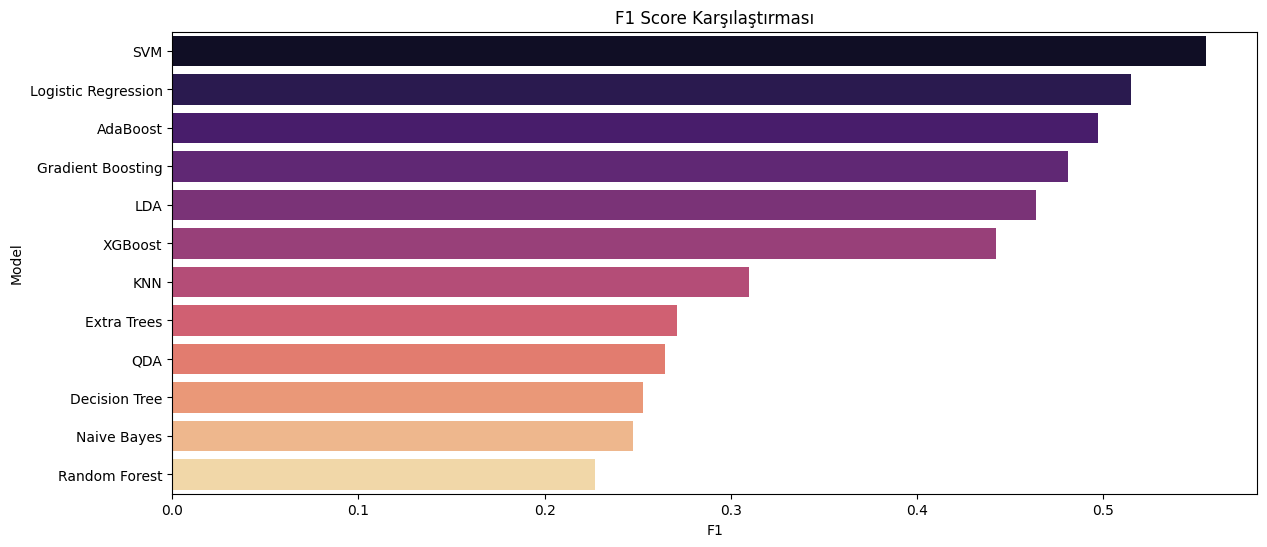

In [20]:
plt.figure(figsize=(14,6))
sns.barplot(data=results_df.sort_values('F1' , ascending=False),
            x='F1' , y='Model' , palette='magma')
plt.title('F1 Score Karşılaştırması')
plt.show()